# Quality Control

In [1]:
# load packages
suppressPackageStartupMessages({
    library(Matrix)
    library(biomaRt)
    library(ggplot2)
    library(knitr)
    library(scales)
    library(viridis)
    library(cowplot)
    library(gridExtra)
})

options(repr.plot.width=15, repr.plot.height=8)

In [3]:
#core functions inc. colour palette
#source("/rds/project/bg200/rds-bg200-hphi-gottgens/users/mlnt2/PhD_MT07_Mixl1/core_functions.R")

main = '/rds/project/rds-SDzz0CATGms/users/bt392/01_Eomes_RNA/'

counts = readMM(paste0(main, "02_calledCells/raw_counts.mtx"))
genes = read.table(paste0(main, "02_calledCells/genes.tsv"), stringsAsFactors = F)
barcodes = read.table(paste0(main, "02_calledCells/barcodes.tsv"), stringsAsFactors = F)[,1]

exp_design = read.csv2(paste0(main, 'experimental_design_meta_eomes.csv'))

out_dir = paste0(main, '03_quality_control/')
dir.create(out_dir, showWarnings = FALSE)

exp_design

Pool,Barcode,Sequence,Sample.name,stage,batch,batch_name,tdTom
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>
SLX-20795,SITTG10,ACTTTACGTG-TGAACGCCCT,MLT_D6 Tom+,E8.5,1,SLX-20795_SITTG10_HKTG2DRXY,positive
SLX-20795,SITTH10,TTATCTAGGG-AAAGGCTCTA,MLT_D6 Tom-,E8.5,2,SLX-20795_SITTH10_HKTG2DRXY,negative
SLX-20795,SITTA11,CGGAACCCAA-GATTCGAGGA,MLT_G9 Tom+,E8.5,3,SLX-20795_SITTA11_HKTG2DRXY,positive
SLX-20795,SITTB11,TCTTACTTGC-TGACCTCTAG,MLT_G9 Tom-,E8.5,4,SLX-20795_SITTB11_HKTG2DRXY,negative
SLX-20795,SITTF11,TTCACACCTT-TAGTGTACAC,MLT_A8+,E8.5,5,SLX-20795_SITTF11_HKTG2DRXY,positive
SLX-20795,SITTG11,GATAACCTGC-CATTAGAAAC,MLT_A8-,E8.5,6,SLX-20795_SITTG11_HKTG2DRXY,negative
SLX-20795,SITTH11,ACAATCGATC-TGACGGAATG,MLT_C7+,E8.5,7,SLX-20795_SITTH11_HKTG2DRXY,positive
SLX-20795,SITTA12,CACCGCACCA-GACTGTCAAT,MLT_C7-,E8.5,8,SLX-20795_SITTA12_HKTG2DRXY,negative


In [4]:
lib.sizes = Matrix::colSums(counts)

split_bc = strsplit(as.character(barcodes), "-", fixed = T)
bcs = sapply(split_bc, function(x) x[1])
samples = sapply(split_bc, function(x) x[2])

In [5]:
head(lib.sizes)

[1] 31003 28276 23751 20794 40272 33907

#### IMPORTANT CORRECTION

Samples are supposed to match with the 'batch' column in exp_design. However, because of the order the 'samples' were assigned, they don't. This needs to be corrected first.

In '02_cell_calling', samples were assigned 1-8 going from 'A11', 'A12', 'B11', 'F11', 'G10', 'G11', 'H10', 'H11'.<br>
In exp_design, batch numbers are assigned as seen above. <br>
Meaning that samples will have to be corrected as followed:<br>
A11: 1 -> 3 <br>
A12: 2 -> 8<br>
B11: 3 -> 4<br>
F11: 4 -> 5<br>
G10: 5 -> 1<br>
G11: 6 -> 6<br>
H10: 7 -> 2<br>
H11: 8 -> 7<br>

In [6]:
correction = data.frame(sample_old = 1:8, sample_new = c(3,8,4,5,1,6,2,7))
samples = data.frame(sample_old = samples)
samples_correction = merge(samples, correction, by = 'sample_old')
samples = samples_correction$sample_new

In [7]:
head(samples)

[1] 3 3 3 3 3 3

In [8]:
###==Cell Complexity Thresholding==###

#=Create function to plot change=#

plot_change = function(barcodes, logical_keep){
  
  pdf = data.frame(Sample = unique(samples),
                   Total = sapply(unique(samples), function(x) sum(samples == x)),
                   Dropped = sapply(unique(samples), function(x) sum(!logical_keep[samples == x])),
                   Retained = sapply(unique(samples), function(x) sum(logical_keep[samples == x])))
  
  p = ggplot(data = pdf) +
          geom_bar(mapping = aes(y = Total, 
                                 x = factor(Sample, levels = unique(samples))), 
                   fill = "darkgrey",
                   stat = "identity") +
          geom_bar(mapping = aes(y = Retained, 
                                 x = factor(Sample, levels = unique(samples))), 
                   fill = "coral",
                   stat = "identity") +
          geom_segment(mapping = aes(y = Total, 
                                     yend = Retained, 
                                     x = factor(Sample, levels = unique(samples)),  
                                     xend = factor(Sample, levels = unique(samples))),
                       arrow = arrow(length = unit(0.1, "inches"))) +
          theme_bw() + 
          theme(text = element_text(size=20)) +
          labs(y = "Number of cells", x= "Sample") 
  
  pdf = rbind(pdf, data.frame(Sample = "Total", 
                              Total = length(barcodes), 
                              Dropped = sum(!logical_keep), 
                              Retained = sum(logical_keep)))
    
  return(list(plot = p, df = pdf))
}

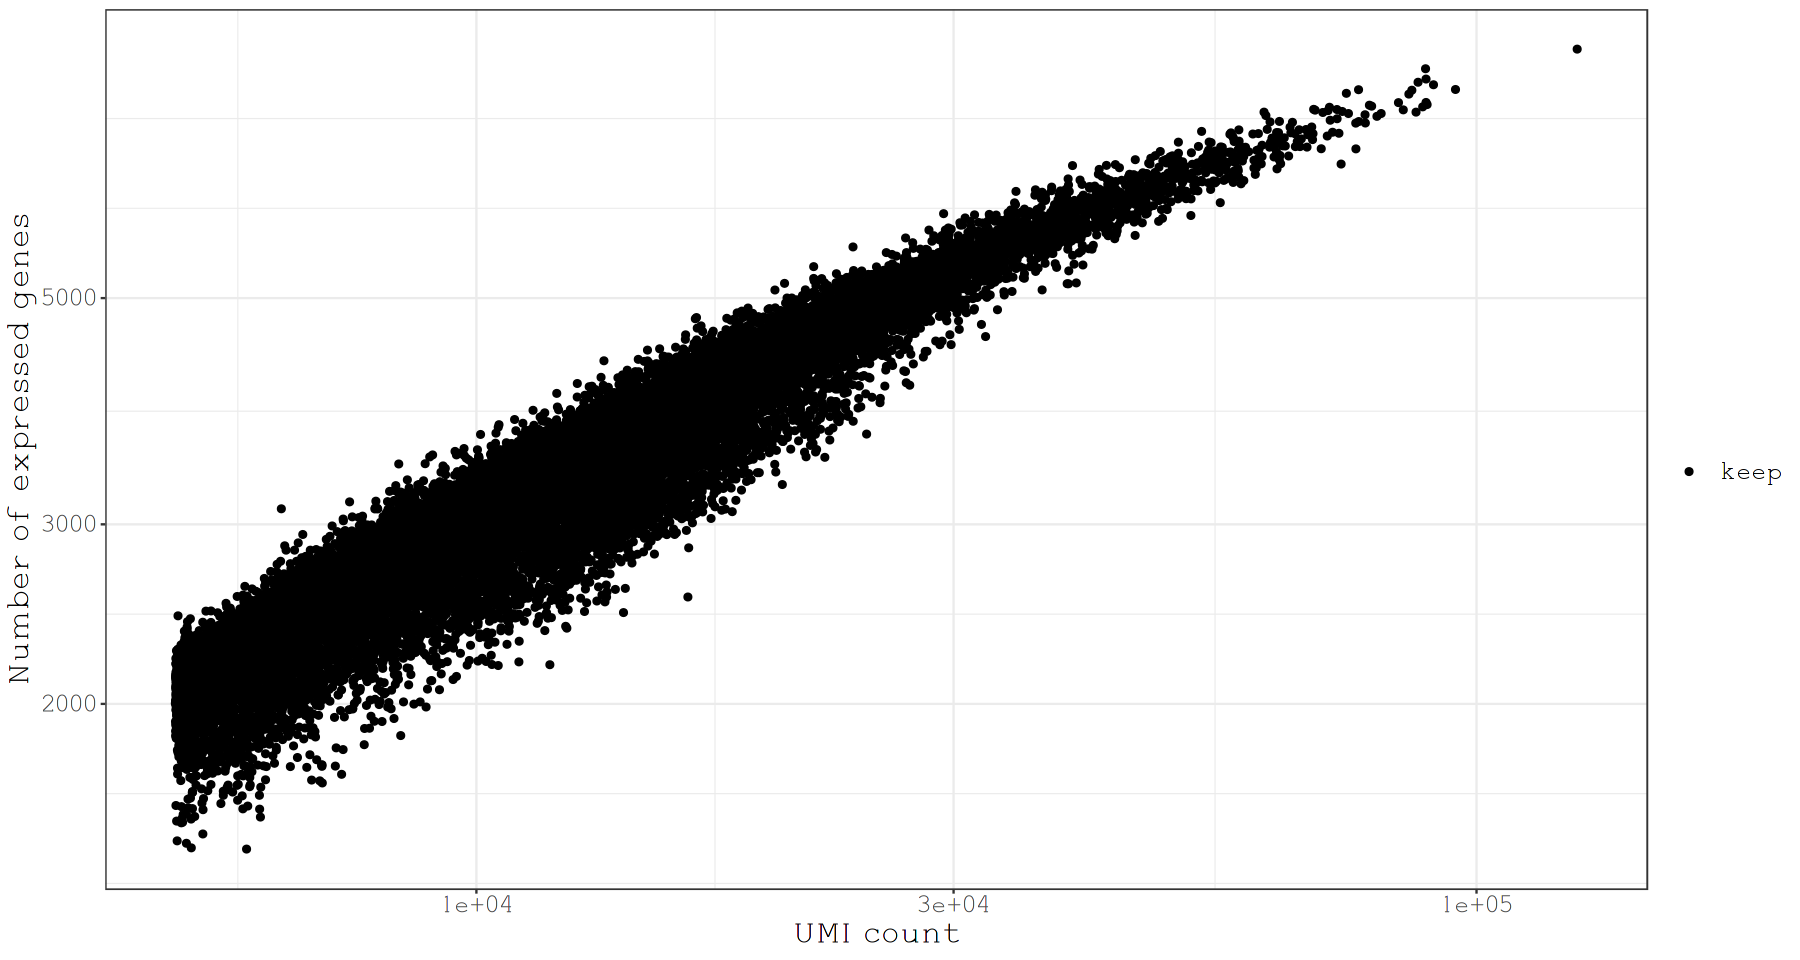

In [9]:
#=Drop cells with low gene counts (<1000)=#

lib.sizes = Matrix::colSums(counts)

ngenes = Matrix::colSums(counts > 0)


p1 = qplot(lib.sizes, ngenes, col = ifelse(ngenes < 1000, "drop", "keep")) +
  scale_x_log10() +
  scale_y_log10() +
  labs(x = "UMI count", y = "Number of expressed genes") +
  scale_color_manual(values = c("drop" = "grey50", "keep" = "black"), name = "") +
  theme_bw() + 
  theme(text = element_text(size=20)) 
p1

In [18]:
min(ngenes)
length(lib.sizes)

[1] 1441

[1] 30946

In [13]:
test = data.frame('size'= lib.sizes, 'ngenes' = ngenes)

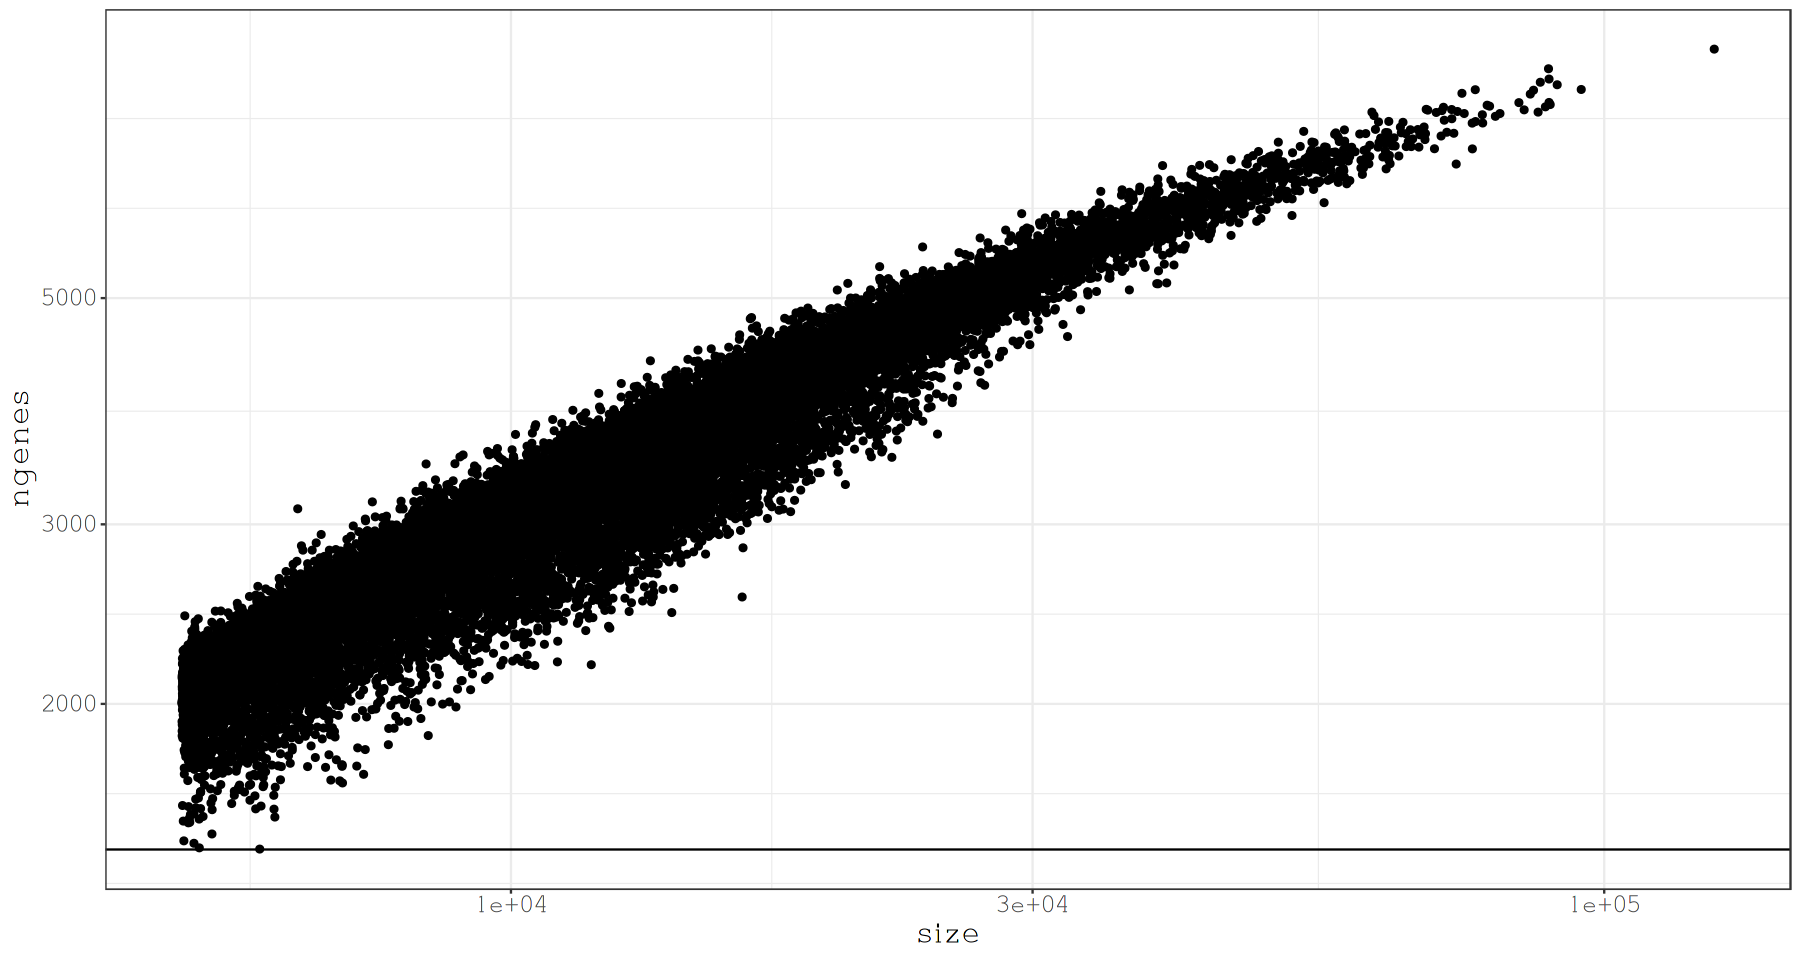

In [24]:
ggplot(test, aes(size, ngenes)) + geom_point() + theme_bw() + geom_hline(yintercept=1441)+ scale_x_log10() + scale_y_log10() +
  theme(text = element_text(size=20)) 

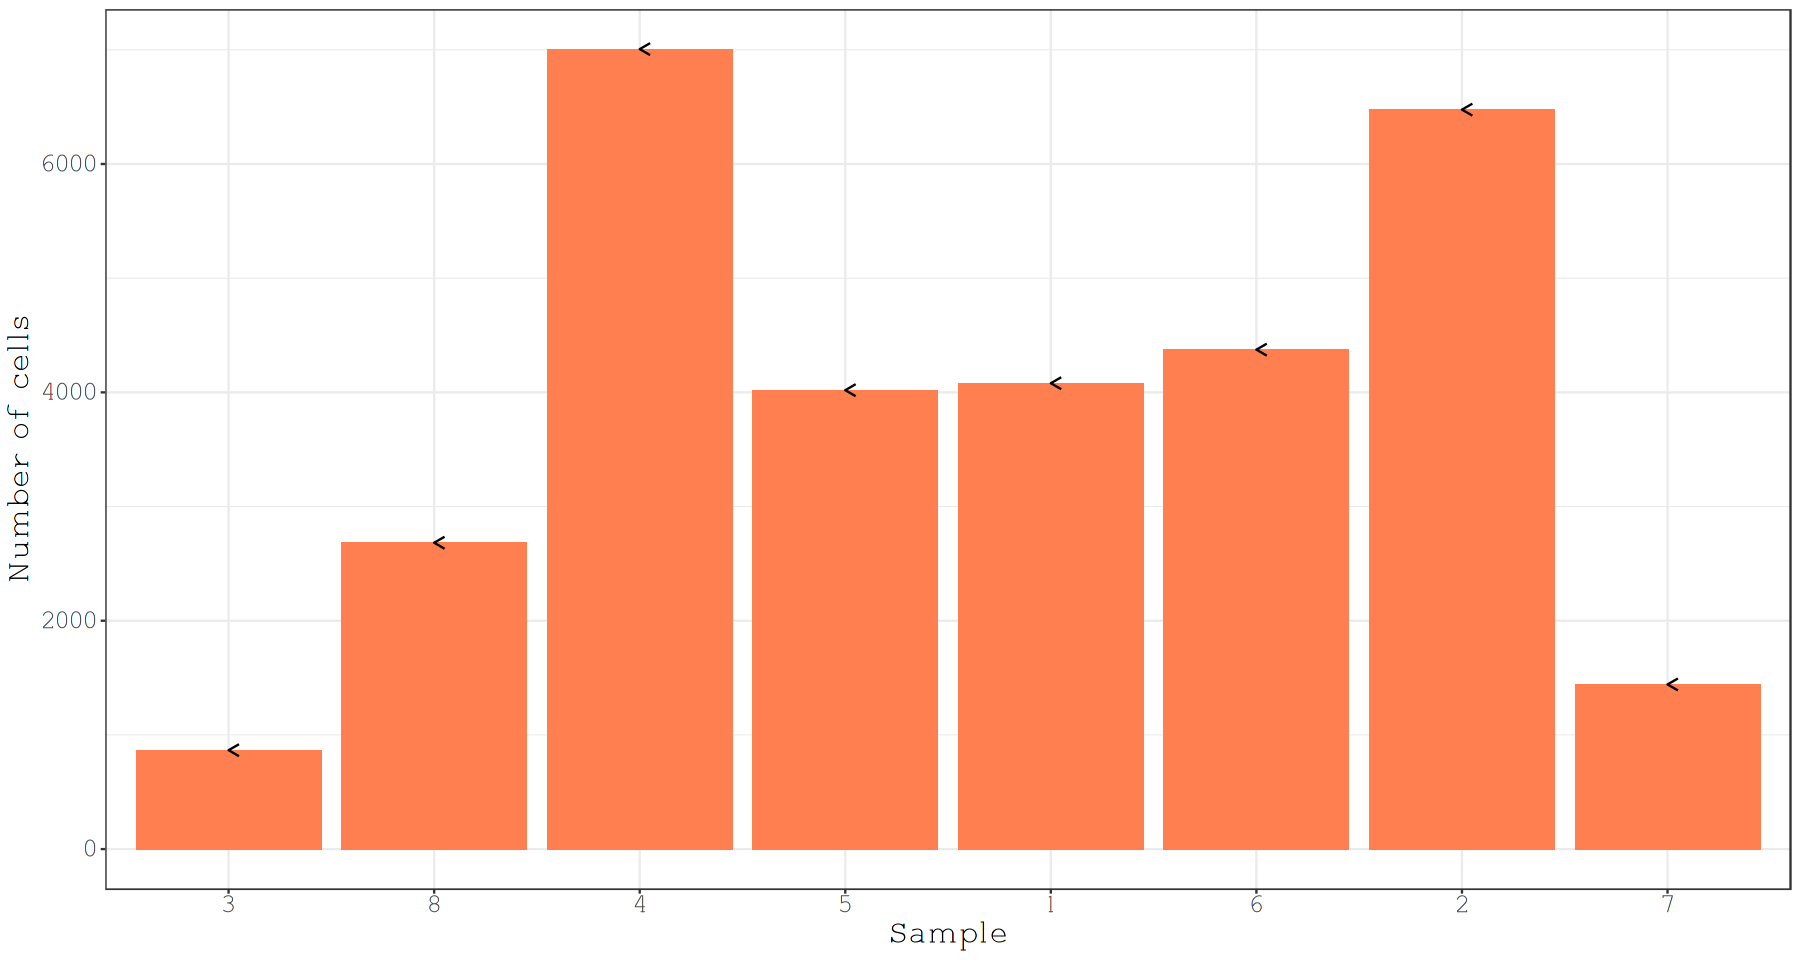

In [226]:
gene_drop = plot_change(barcodes, logical_keep = ngenes > 1000 )

print(gene_drop$plot)

In [227]:
kable(gene_drop$df, caption = "Cells dropped according to low library complexity thresholding.", row.names = FALSE)



Table: Cells dropped according to low library complexity thresholding.

|Sample | Total| Dropped| Retained|
|:------|-----:|-------:|--------:|
|3      |   866|       0|      866|
|8      |  2683|       0|     2683|
|4      |  7006|       0|     7006|
|5      |  4019|       0|     4019|
|1      |  4080|       0|     4080|
|6      |  4374|       0|     4374|
|2      |  6476|       0|     6476|
|7      |  1442|       0|     1442|
|Total  | 30946|       0|    30946|

In [228]:
counts = counts[, ngenes > 1000]
barcodes = barcodes[ngenes > 1000]
bcs = bcs[ngenes > 1000]
samples = samples[ngenes > 1000]
ngenes = ngenes[ngenes > 1000]

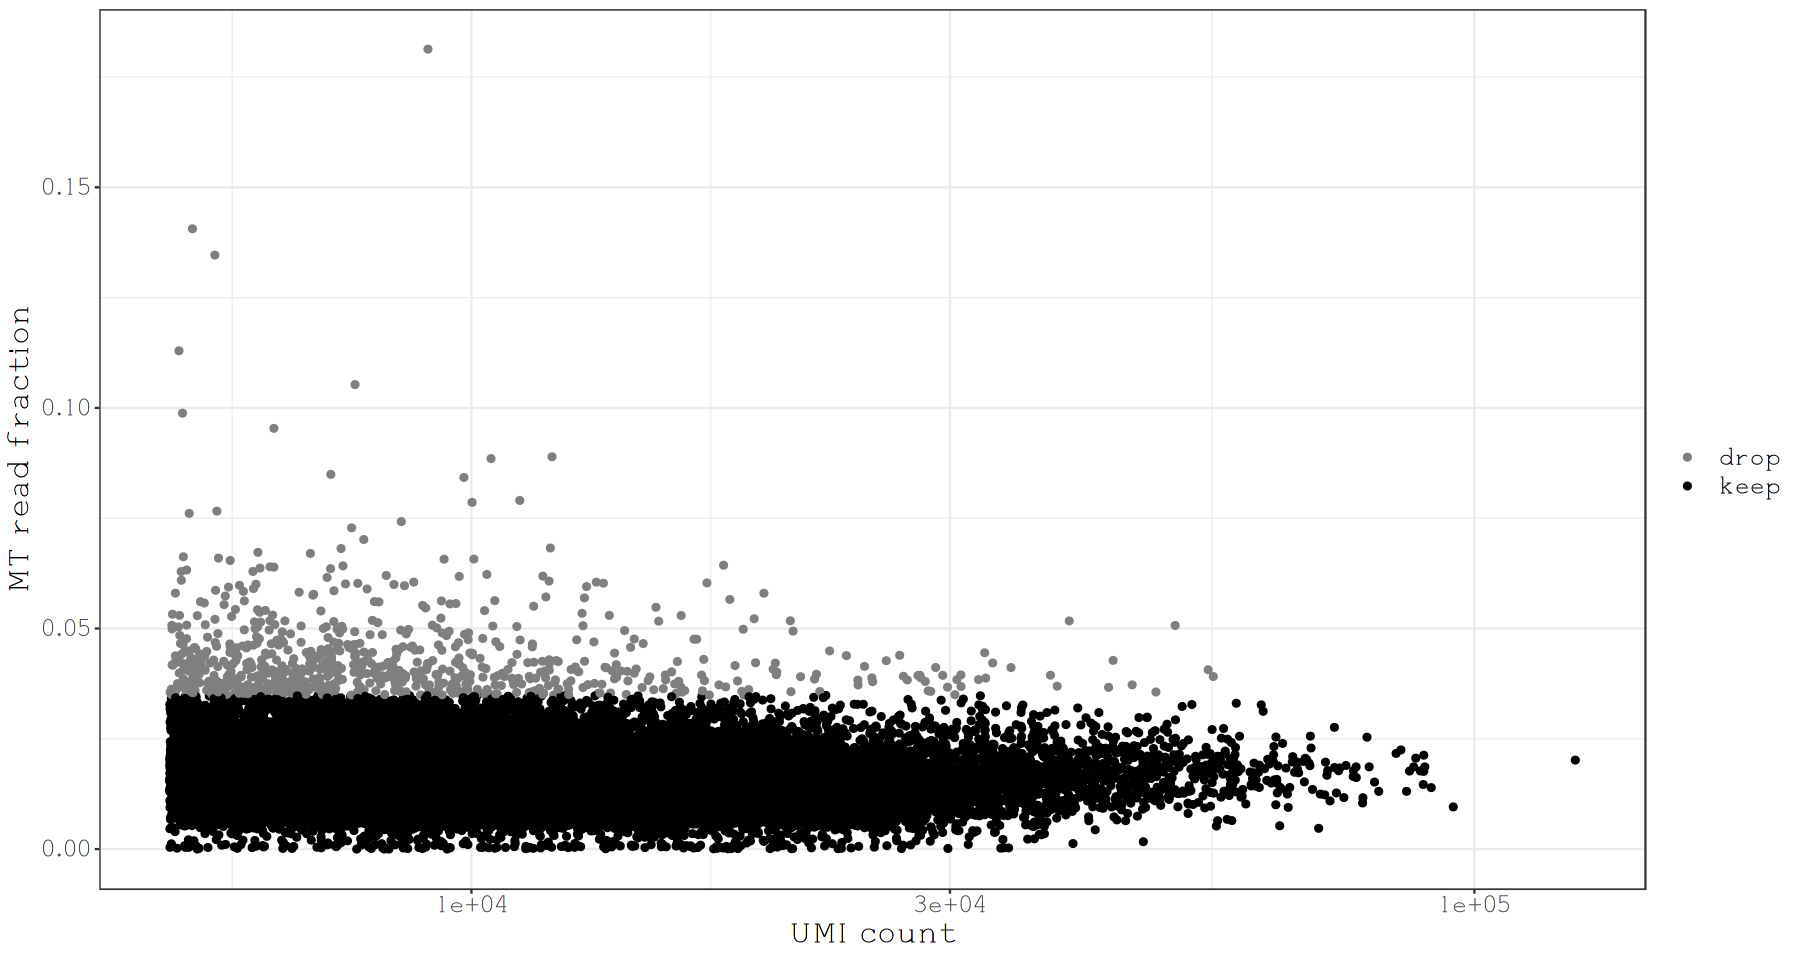

In [229]:
##==Filter cells based on high MT fraction (stressed, apoptotic cells)==##

lib.sizes = colSums(counts)

mouse_ensembl = useMart("ensembl")
mouse_ensembl = useDataset("mmusculus_gene_ensembl", mart = mouse_ensembl)

gene_map = getBM(attributes=c("ensembl_gene_id", "chromosome_name"), values = genes, mart = mouse_ensembl)
mt.counts = counts[which(genes[,1] %in% gene_map$ensembl_gene_id[gene_map$chromosome_name=="MT"]),]
mt.fraction = colSums(mt.counts)/lib.sizes

#fit median-centered, MAD-variance normal 
#crass 5%+
# mt.lim = qnorm(0.95, mean = median(mt.fraction), sd = mad(mt.fraction))
#fdr-corrected outliers
#technically this should be a pt, but the df. is astronomically high so this is essentially the same
mt.p = pnorm(mt.fraction, mean = median(mt.fraction), sd = mad(mt.fraction), lower.tail = FALSE)
mt.lim = min(mt.fraction[which(p.adjust(mt.p, method = "fdr") < 0.05)])

p2 = qplot(lib.sizes, mt.fraction, col = ifelse(mt.fraction>mt.lim, "drop", "keep")) +
  scale_x_log10() +
  labs(x = "UMI count", y = "MT read fraction") +
  scale_color_manual(values = c("drop" = "grey50", "keep" = "black"), name = "") + 
  theme_bw() + 
  theme(text = element_text(size=20)) 
p2

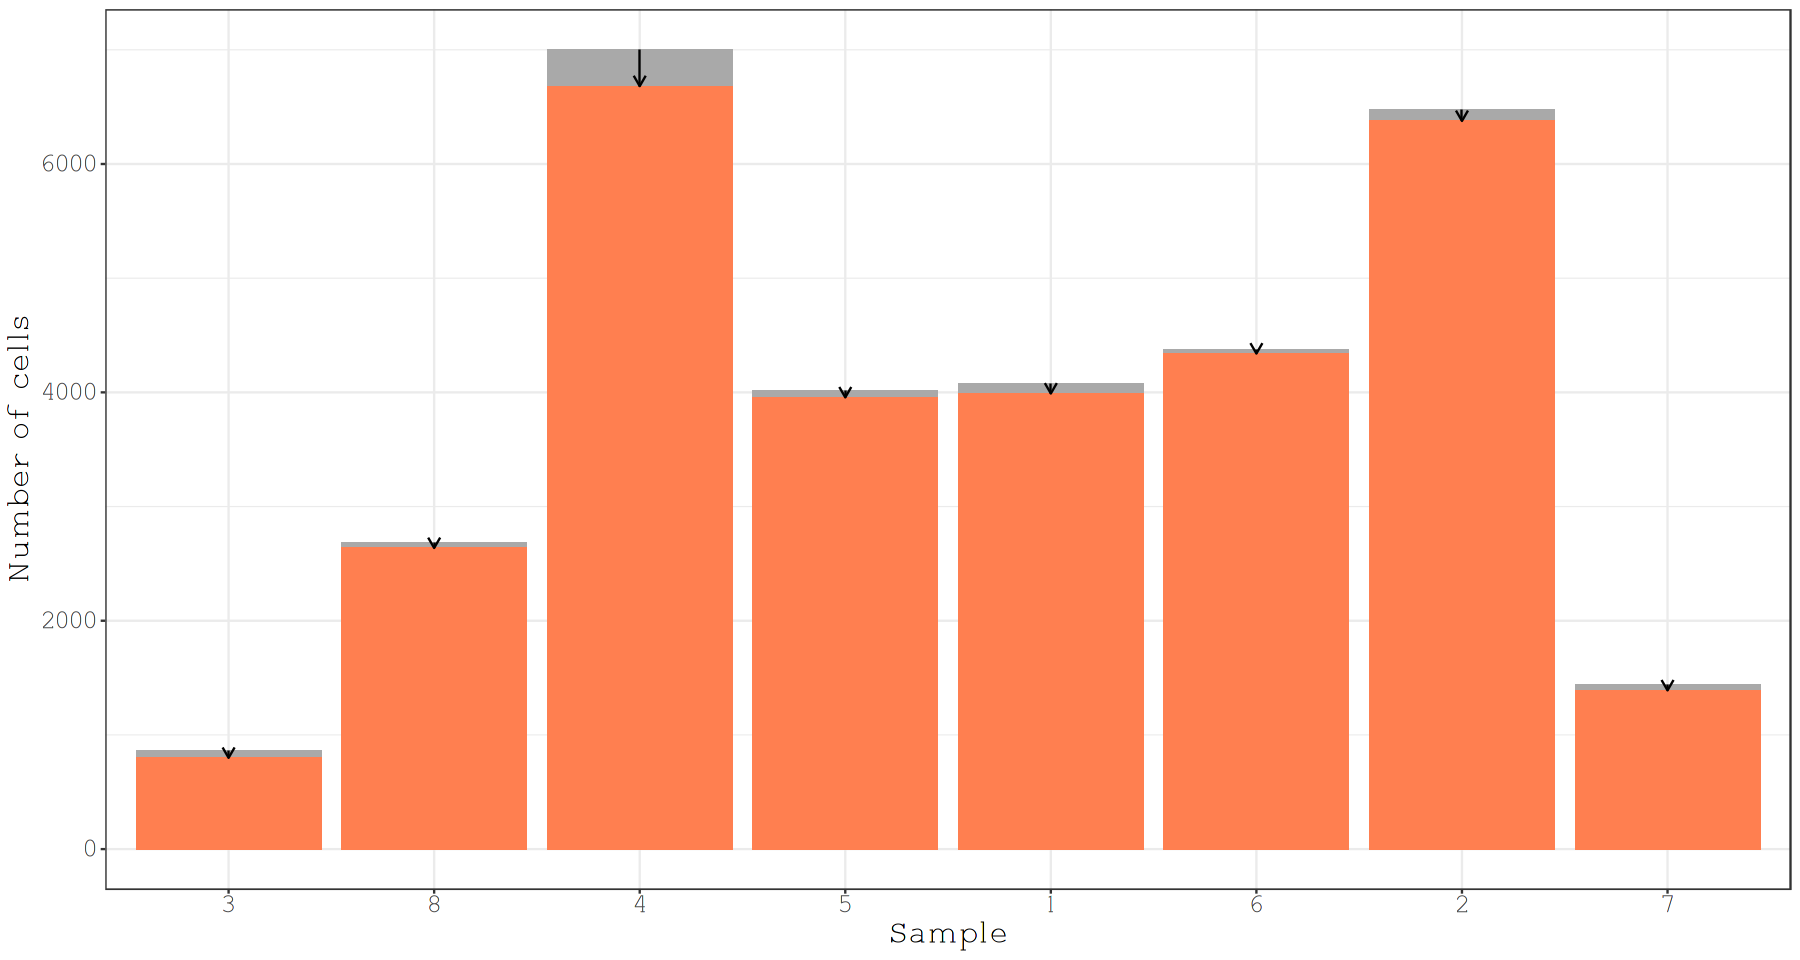

In [230]:
mt_drop = plot_change(barcodes, logical_keep = mt.fraction<mt.lim )

print(mt_drop$plot)

In [231]:
kable(mt_drop$df, caption = "Cells dropped according to mitochondrial fraction threshold", row.names = FALSE)



Table: Cells dropped according to mitochondrial fraction threshold

|Sample | Total| Dropped| Retained|
|:------|-----:|-------:|--------:|
|3      |   866|      67|      799|
|8      |  2683|      46|     2637|
|4      |  7006|     324|     6682|
|5      |  4019|      63|     3956|
|1      |  4080|      90|     3990|
|6      |  4374|      34|     4340|
|2      |  6476|      99|     6377|
|7      |  1442|      52|     1390|
|Total  | 30946|     775|    30171|

In [232]:
counts = counts[, mt.fraction < mt.lim]
barcodes = barcodes[mt.fraction < mt.lim]
bcs = bcs[mt.fraction < mt.lim]
samples = samples[mt.fraction < mt.lim]
mt.fraction = mt.fraction[mt.fraction < mt.lim]

# Number of detected genes

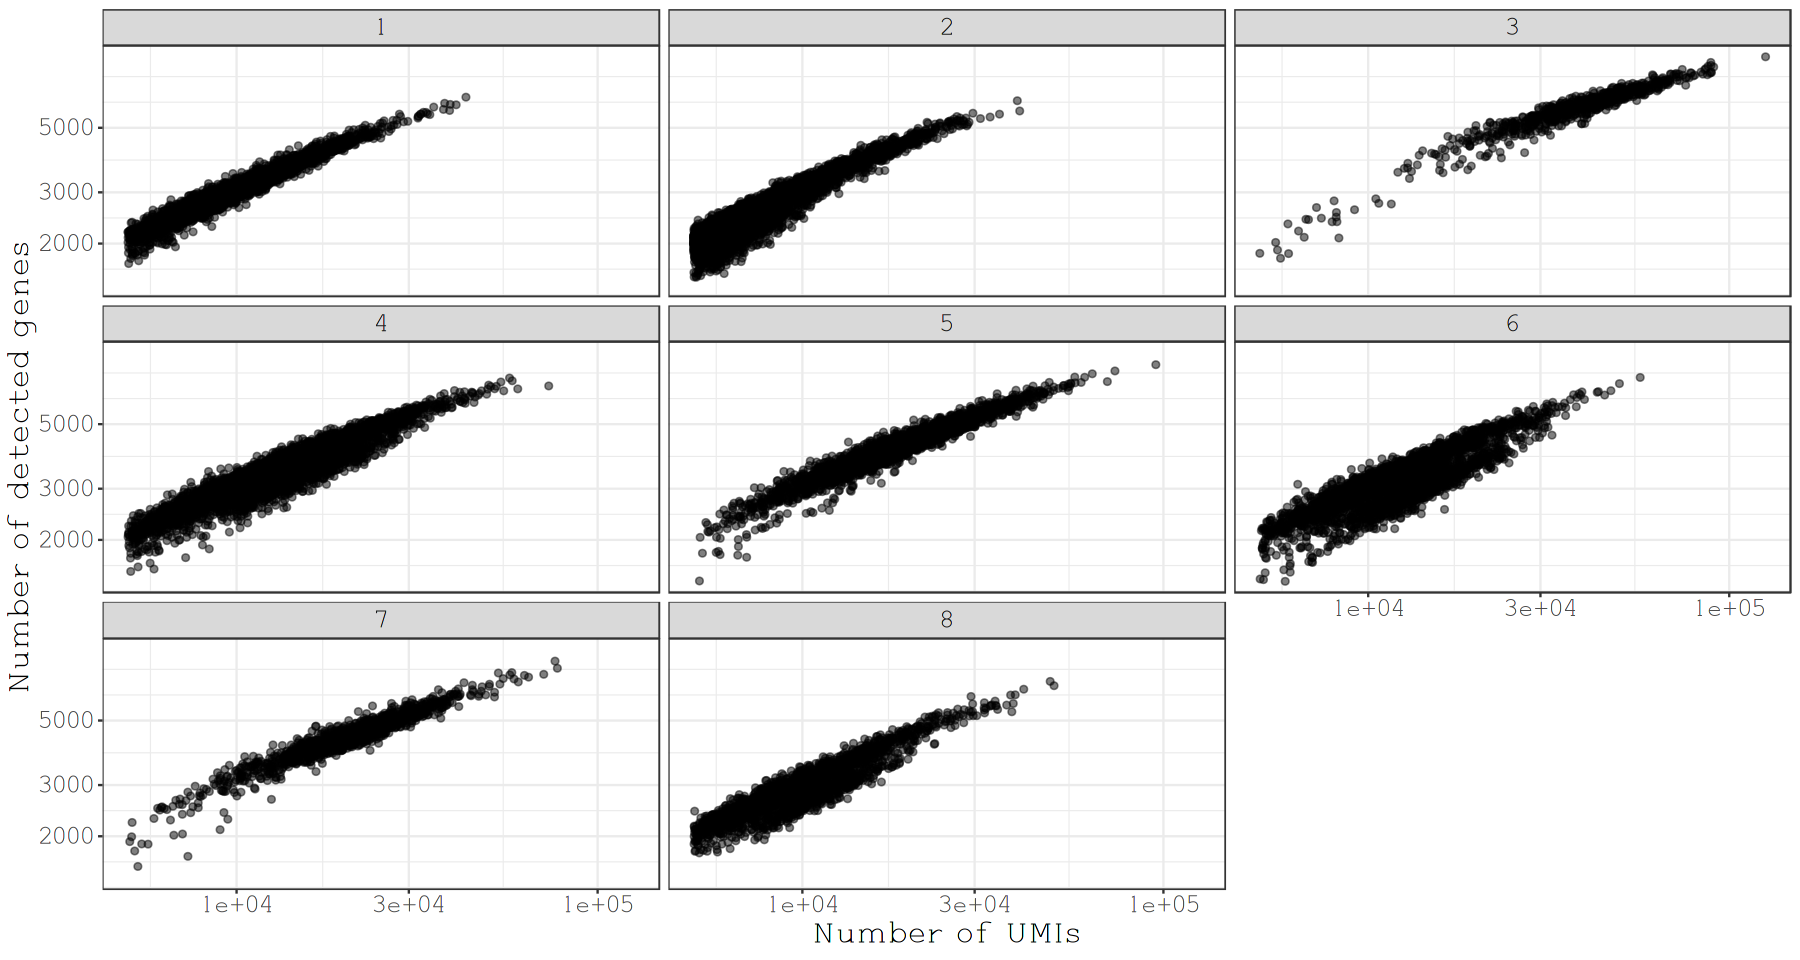

In [233]:
lib.sizes = colSums(counts)
n.genes = colSums(counts>0)

plot_df = data.frame(lib = lib.sizes, genes = n.genes, sample = samples)
plot_df = plot_df[sample(nrow(plot_df), nrow(plot_df), replace = FALSE),]

p3 = ggplot(plot_df, aes(x = lib, y = genes)) +
  geom_point(alpha = 0.5) +
 # scale_colour_Publication() +
  scale_y_log10() +
  scale_x_log10() +
  theme_bw() +
  theme(text = element_text(size=20)) +
  facet_wrap(~factor(sample, levels = unique(sample)[order(nchar(unique(as.character(sample))), unique(sample))]), ncol = 3) +
  labs(x = "Number of UMIs", y = "Number of detected genes")

suppressWarnings(plot(p3))

# Inter-sample Comparisons

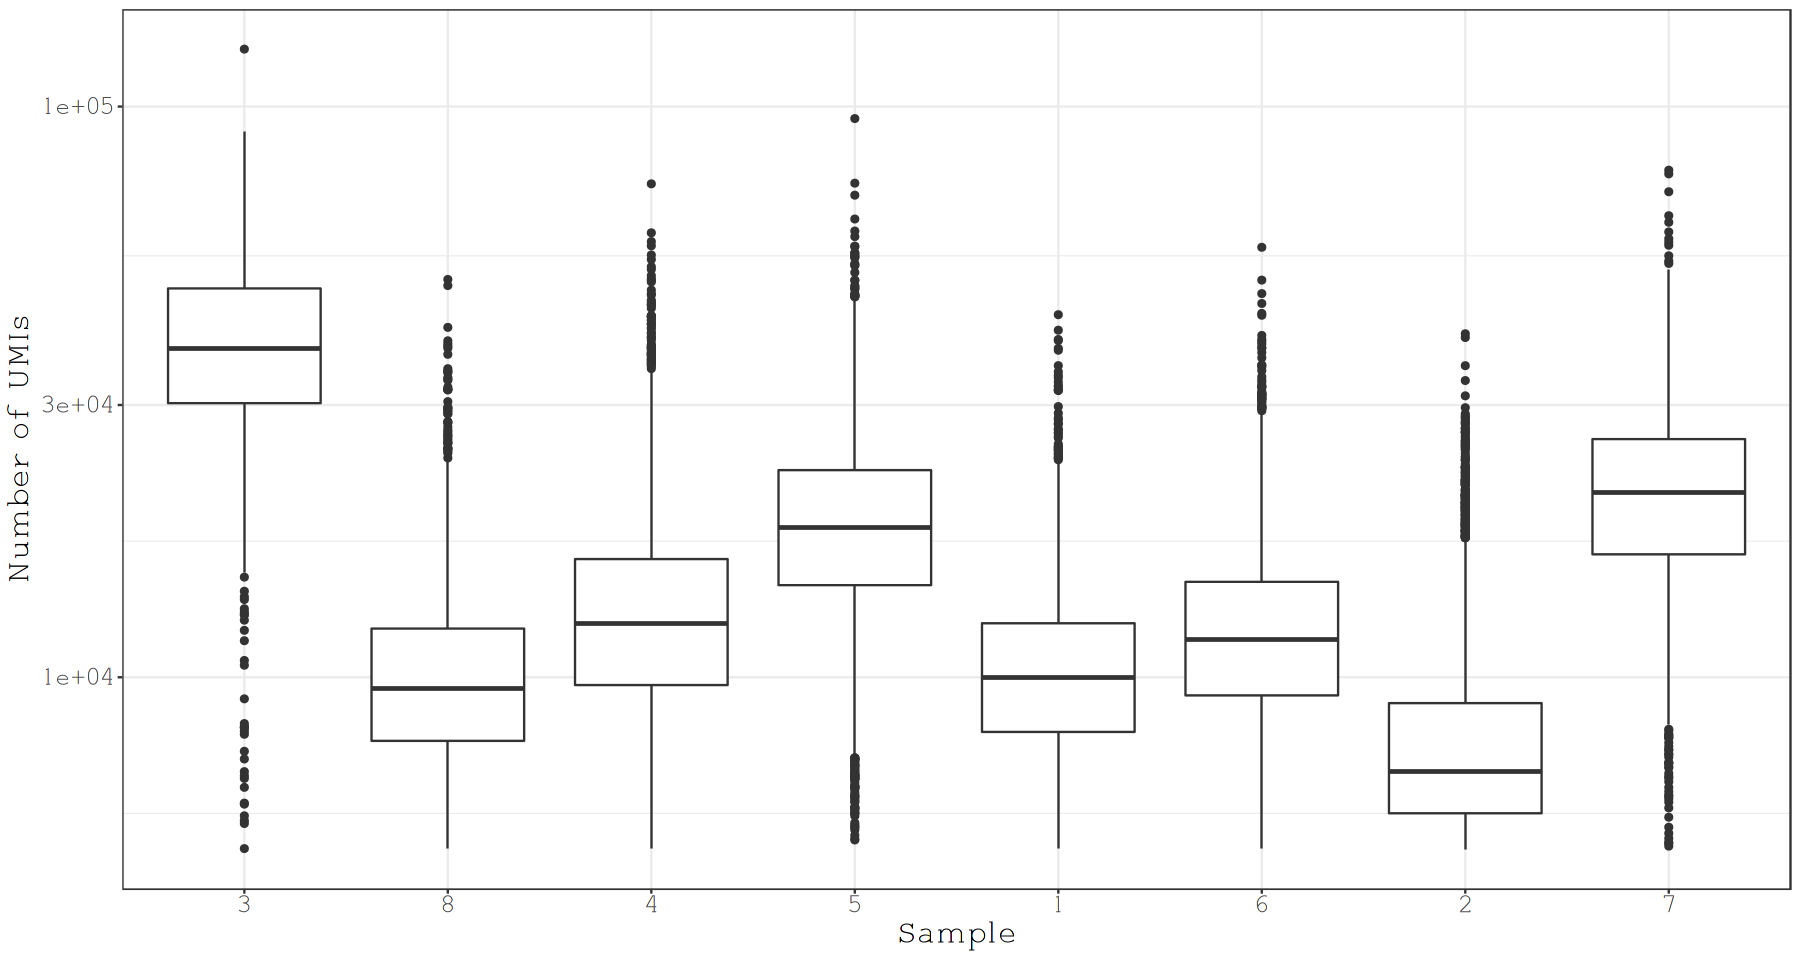

In [234]:
p4 = ggplot(data.frame(lib = lib.sizes, sample = samples), aes (x = factor(sample, levels = unique(sample)), 
                                                           y = lib.sizes)) +
  geom_boxplot() +
  theme_bw() +
  theme(text = element_text(size=20),legend.position = "none") +
  scale_y_log10() +
  labs(x = "Sample", y = "Number of UMIs")+
  scale_color_brewer(palette = "Set1", name = "Sequencing\nbatch")

suppressWarnings(plot(p4))

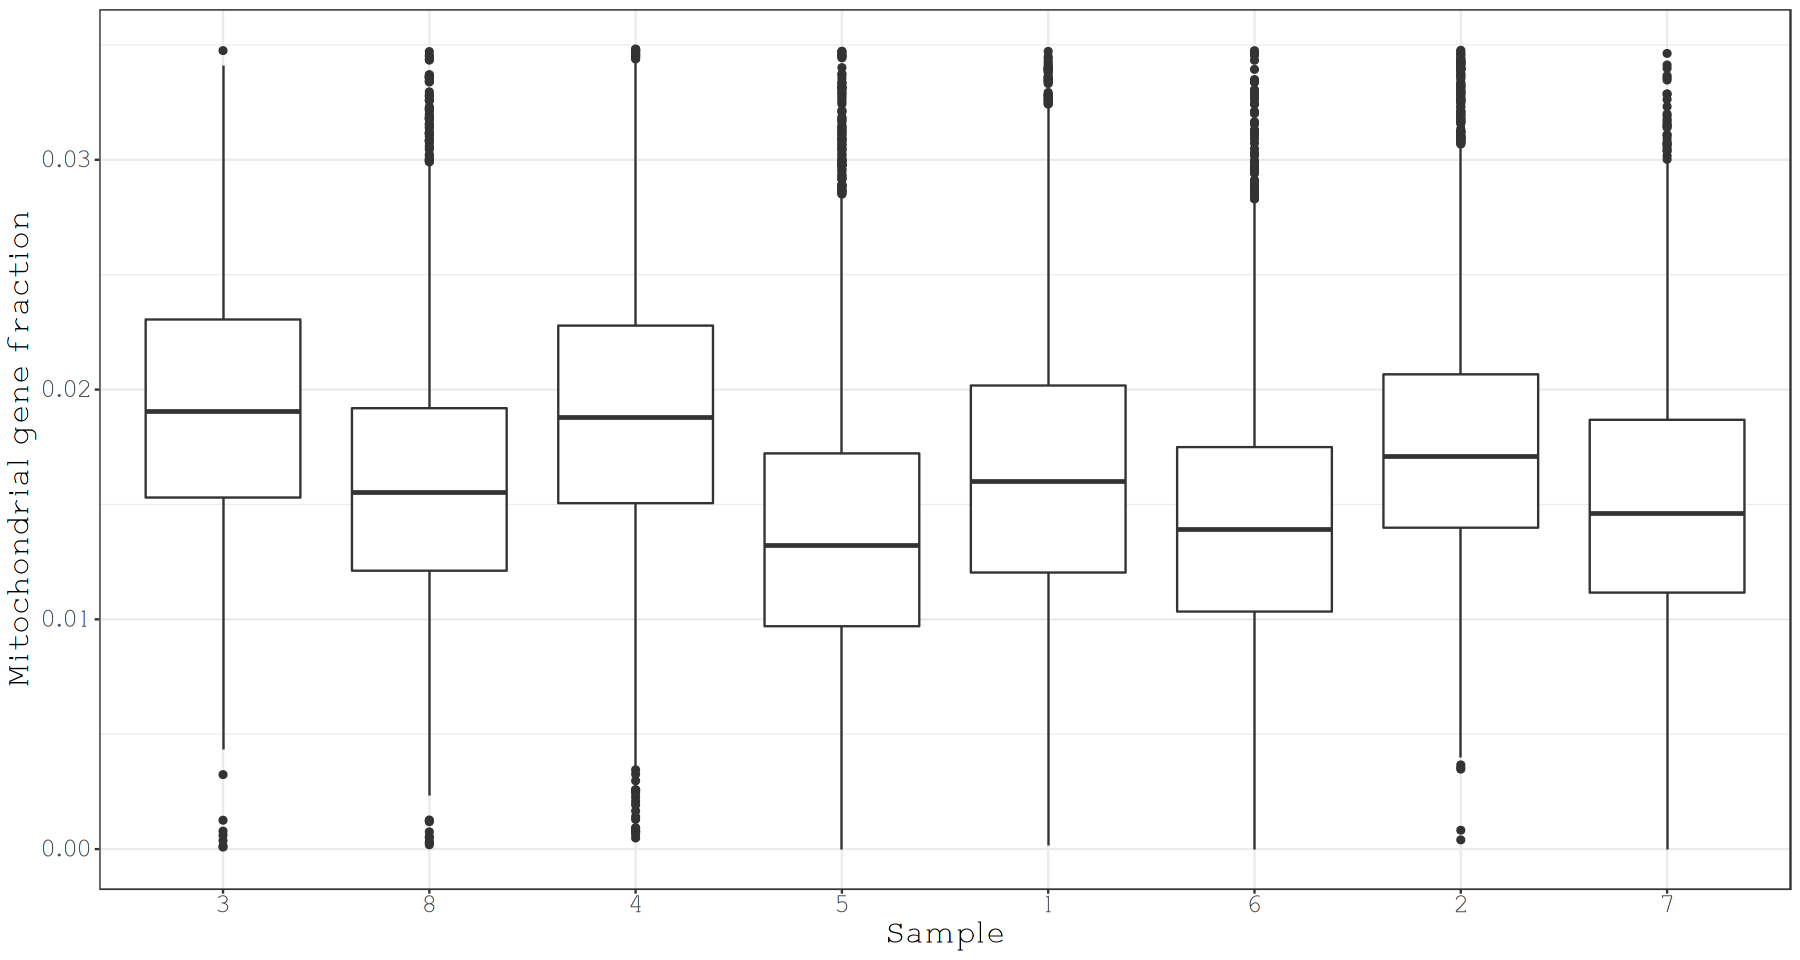

In [235]:
p5 = ggplot(data.frame(mt = mt.fraction, sample = samples), aes (x = factor(sample, levels = unique(sample)), 
                                                           y = mt)) +
  geom_boxplot() +
  theme_bw() + 
  theme(text = element_text(size=20),legend.position = "none") +
 # scale_y_log10() +
  labs(x = "Sample", y = "Mitochondrial gene fraction") +
  scale_color_brewer(palette = "Set1", name = "Sequencing\nbatch")

suppressWarnings(plot(p5))

In [236]:
meta = data.frame(cell = paste0("cell_", 1:ncol(counts)),
                  barcode = bcs,
                  stage = exp_design$stage[match(samples, exp_design$batch)],
                  batch = exp_design$batch[match(samples, exp_design$batch)],
                  Sample_name = exp_design$Sample.name[match(samples, exp_design$batch)],
                  batch_name = exp_design$batch_name[match(samples, exp_design$batch)],
                  tdTom = exp_design$tdTom[match(samples, exp_design$batch)]
                )

In [237]:
tail(meta)

,cell,barcode,stage,batch,Sample_name,batch_name,tdTom
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>
30166,cell_30166,TTTGGTTCAGTCCCGA,E8.5,7,MLT_C7+,SLX-20795_SITTH11_HKTG2DRXY,positive
30167,cell_30167,TTTGGTTGTTGTGCCG,E8.5,7,MLT_C7+,SLX-20795_SITTH11_HKTG2DRXY,positive
30168,cell_30168,TTTGGTTTCATGGTAC,E8.5,7,MLT_C7+,SLX-20795_SITTH11_HKTG2DRXY,positive
30169,cell_30169,TTTGGTTTCGGTGTAT,E8.5,7,MLT_C7+,SLX-20795_SITTH11_HKTG2DRXY,positive
30170,cell_30170,TTTGTTGCAATGAGCG,E8.5,7,MLT_C7+,SLX-20795_SITTH11_HKTG2DRXY,positive
30171,cell_30171,TTTGTTGCATATGCGT,E8.5,7,MLT_C7+,SLX-20795_SITTH11_HKTG2DRXY,positive


In [238]:
tab = as.matrix(table(meta$batch, meta$stage))

new_rownames = c("Total", rownames(tab))
tab = rbind(sapply(colnames(tab), function(x) sum(meta$stage == x)),
            tab)
rownames(tab) = new_rownames

pt = kable(tab, caption = "Number of cells retained for analysis")
pt



Table: Number of cells retained for analysis

|      |  E8.5|
|:-----|-----:|
|Total | 30171|
|1     |  3990|
|2     |  6377|
|3     |   799|
|4     |  6682|
|5     |  3956|
|6     |  4340|
|7     |  1390|
|8     |  2637|

# tomato check

In [239]:
tdtom_count = counts[nrow(counts),]
tdtom_exp = data.frame('tdtom_count' = tdtom_count, 'batch' = samples)
tdtom_exp = merge(tdtom_exp, exp_design, by='batch')

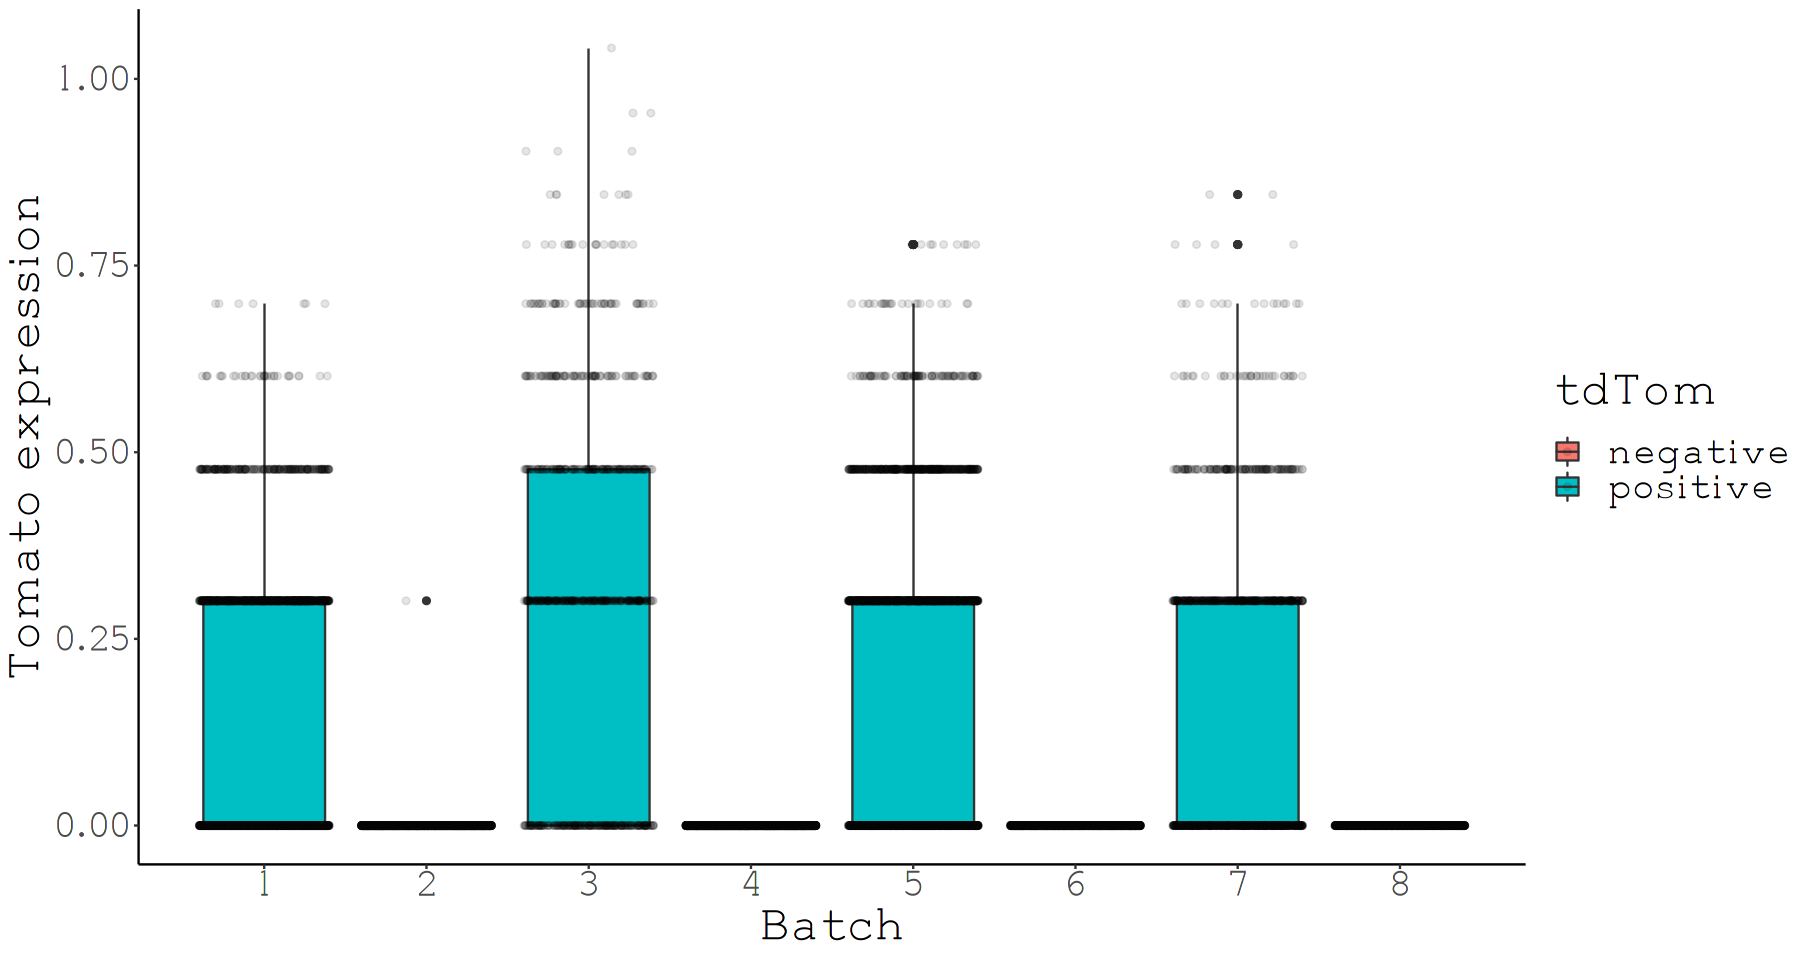

In [273]:
p6 = ggplot(tdtom_exp, aes(as.factor(batch), log10(tdtom_count+1), group=batch, fill=tdTom)) + 
    geom_boxplot() +
    geom_point(position = position_jitterdodge(jitter.width =0.8), alpha=0.1) +
    theme_classic() + 
    theme(text = element_text(size=30)) + 
    xlab('Batch') + ylab('Tomato expression')
p6
## Result is as expected, will probably look better after normalisation/scaling

### Save files & plots

In [209]:
# Save files
null_holder = writeMM(counts, file = paste0(out_dir,"matrix.mtx"))
saveRDS(as(counts, "dgCMatrix"), file = paste0(out_dir,"raw_counts.rds"))
write.table(barcodes, file = paste0(out_dir,"barcodes.tsv"), row.names = F, col.names = F, quote = F, sep = "\t")
write.table(meta, file = paste0(out_dir,"meta.tab"), row.names = F, col.names = T, quote = F, sep = "\t")

In [274]:
ggsave(filename=paste0(out_dir, 'quality_control_output.png'),
       grid.arrange(p1,gene_drop$plot, p2,mt_drop$plot, p3, p4,p5,p6 ,ncol=2),
       device='png',
       width=15, height=25)

In [203]:
sessionInfo()

R version 4.0.3 (2020-10-10)
Platform: x86_64-pc-linux-gnu (64-bit)
Running under: Manjaro Linux

Matrix products: default
BLAS:   /usr/local/lib64/R/lib/libRblas.so
LAPACK: /usr/local/lib64/R/lib/libRlapack.so

locale:
 [1] LC_CTYPE=en_GB.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_GB.UTF-8        LC_COLLATE=en_GB.UTF-8    
 [5] LC_MONETARY=en_GB.UTF-8    LC_MESSAGES=en_GB.UTF-8   
 [7] LC_PAPER=en_GB.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_GB.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] dplyr_1.0.4.9000  cowplot_1.1.1     viridis_0.5.1     viridisLite_0.3.0
[5] scales_1.1.1      knitr_1.30        ggplot2_3.3.3     biomaRt_2.46.0   
[9] Matrix_1.2-18    

loaded via a namespace (and not attached):
 [1] Rcpp_1.0.6           lattice_0.20-41      prettyunits_1.1.1   
 [4] getPass_0.